# Визуализация агрегации

In [29]:
from disk_analyzer.research.paths import artifacts_dir
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from disk_analyzer.research.config import DEFAULT_TIMES as TIMES
from disk_analyzer.research.aggregation.predictions_aggregator import PredictionsAggregator
from disk_analyzer.models.MagiCox import MagiCoxTimeVaryingEstimator
import pickle
import matplotlib.cm as cm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXP_NUM = 68
RES_FOLDER = str(artifacts_dir(EXP_NUM))
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
BATCH_SIZE = 1024
DATA = 'Preprocessed_new/30_25_test_preprocessed.csv'
AGG_MODE = 't_dist'
AGG_WEIGHT = 0.1

In [ ]:
with open(os.path.join(MODELS_FOLDER, '127_Cox_model.pkl'), 'rb') as f:
    model = pickle.load(f)
# model.__class__ = MagiCoxTimeVaryingEstimator

In [31]:
df_test = pd.read_csv(DATA)
print(df_test[df_test['failure'] == 0]['serial_number'].unique())
print(df_test[df_test['failure'] == 1]['serial_number'].unique())

['13H87YWAS' '13H8AB0GS' '13H8B3SGS' ... 'ZA18CCWM' 'ZCH05TTR' 'ZCH068F2']
['5732PE2OT' '96ICTBQIT' '9QM04GKZ' 'JK1101B9J301EF' 'JK1101B9JP60TU'
 'JK1104B8GGGBXW' 'JK1105B8GHWJZX' 'JK1105B8J10GXX' 'JK1105B8JS2ELX'
 'JK1131YAHP3NEV' 'JK1171YAK2045N' 'JK11A8B9J67Z0F' 'JK11A8B9J90WMF'
 'MJ0351YNG9Z5WA' 'MJ0351YNGA6Z8A' 'MJ1311YNG36USA' 'MJ1311YNG5XS1A'
 'MJ1311YNG733NA' 'MJ1311YNG7LWAA' 'MJ1313YNG0ZL2C' 'MJ1313YNG1VEUC'
 'MJ1321YNG09HRA' 'MJ1321YNG0JU6A' 'MK0311YHGEZB3A' 'MK0313YHGGJ4PC'
 'MK0333YHGPJERC' 'PL1301LAG3594H' 'PL1321LAG34N8H' 'PL1321LAGAXVMH'
 'PL1331LAGLXSHH' 'PL1331LAGRUENH' 'PL1331LAGRZ3DH' 'PL1331LAGS94VH'
 'PL1331LAGSDZXH' 'PL1331LAGSGR2H' 'PL1331LAGT941H' 'PL1331LAGTH4PH'
 'PL1331LAHBSRGH' 'PL1331LAHBXGDH' 'PL1331LAHD0UAH' 'PL1331LAHD10SH'
 'PL1331LAHD16PH' 'PL1331LAHD32MH' 'PL1331LAHD5SDH' 'PL1331LAHDDWUH'
 'PL1331LAHE0WLH' 'PL1331LAHE0X1H' 'PL1331LAHE1MDH' 'PL1331LAHESYPH'
 'PL1331LAHGVAUH' 'PL2331LAG9LE4J' 'PL2331LAG9RB7J' 'PL2331LAG9W4YJ'
 'PL2331LAGMZ8XJ' 'PL2331LA

In [32]:
TICK_SIZE = 10
def plot_predictions(X_pred, times, ax, shift_pred=True, max_times = np.inf):


    cmap = cm.viridis
    num_lines = len(X_pred)
    colors = [cmap(i / max(num_lines - 1, 1)) for i in range(num_lines)]
    max_time = X_pred['time'].max()

    times_str = set(map(str, times))
    times_cols = [col for col in X_pred.columns if str(col) in times_str]
    for i, (index, row) in enumerate(X_pred.iterrows()):
        
        if not shift_pred:
            cur_times = times[times < max_times]
            ax.plot(
                cur_times,
                row[times_cols].values[:len(cur_times)], 
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
        else:
            cur_times = times - (max_time - row.values[1])  
            ax.plot(
                cur_times[cur_times < max_times],
                row[times_cols].values[:len(cur_times[cur_times < max_times])], #TODO: до len() делать не вполне правильно, потом надо пофиксить
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
    ax.set_title('Predictions')
    ax.grid(True)
    return ax

def plot_disk_predictions(X_pred, serial_number, last_observ_n, amount_observ, times, ax = None, shift_pred=True, X_gt = None, plot_event = True, max_times = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number]
    cur_X_pred = cur_X_pred.sort_values(by=['time']).head(last_observ_n).tail(amount_observ)
    ax = plot_predictions(cur_X_pred, times, ax, shift_pred=shift_pred, max_times = max_times)
    if X_gt is not None:
        if plot_event:
            cur_X_gt = X_gt[X_gt['serial_number'] == serial_number] 
            last_time = cur_X_pred.iloc[-1, 1]
            last_duration = cur_X_gt[cur_X_gt['time'] == last_time]['duration'].values[0]
            event = cur_X_gt['failure'].max() == True
            plot_event_line(last_duration, event, ax, TICK_SIZE)
    return ax

def plot_event_line(time, event, ax, fontsize=TICK_SIZE):
    event_color = 'r' if event else 'b'
    ax.axvline(x=time, color=event_color, linestyle='--', linewidth=2)

    # Подописываем момент исхода
    x_fraction = ax.transData.transform((time, 0))[0]
    x_fraction = ax.transAxes.inverted().transform((x_fraction, 0))[0]

    ax.annotate(
        f'{time}',
        xy=(x_fraction, -0.05),       
        xycoords='axes fraction',
        ha='center',
        va='top',
        fontsize=fontsize,
        color=event_color
    )

def get_chain_survival_predictions_for_disk(
    X_pred,
    serial_number,
    times,
    sample_grid,
    pred_agg,
    agg_method,
    agg_weight,
    X_gt=None,
    last_observ_n=None
):
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number].sort_values(by=['time'])

    if last_observ_n is not None:
        cur_X_pred = cur_X_pred.head(last_observ_n)

    max_chain_len = cur_X_pred.shape[0]
    rows = []
    event = None
    duration = None

    for chain_len in sample_grid:
        if chain_len > max_chain_len:
            continue

        chain = cur_X_pred.tail(chain_len)
        timeshift = chain['time'].max() - chain['time']

        aggregated_pred = pred_agg.predict(chain, times, timeshift=timeshift)
        times_str = set(map(str, times))
        times_cols = [col for col in aggregated_pred.columns if str(col) in times_str]
        survival_curve = aggregated_pred[times_cols].iloc[0].values

        rows.append({
            'chain_len': chain_len,
            'agg_method': agg_method,
            'agg_weight': agg_weight,
            'survival': survival_curve
        })

        if X_gt is not None and event is None and duration is None:
            cur_X_gt = X_gt.loc[cur_X_pred.index]
            event = cur_X_gt['failure'].max()
            duration = cur_X_gt['duration'].min()

    return pd.DataFrame(rows), event, duration


def plot_survival_chains(df, times, ax=None, plot_event=False, event=None, duration=None, max_times = np.inf):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    num_lines = len(df)
    cmap = cm.plasma
    colors = [cmap(i / max(num_lines-1, 1)) for i in range(num_lines)]

    for i, row in enumerate(df.itertuples()):
        ax.plot(times[times < max_times], row.survival[times < max_times], color=colors[i], label=f'len={row.chain_len}', linewidth=2)

    method = df['agg_method'].iloc[0]
    weight = df['agg_weight'].iloc[0]

    if plot_event:
        if event is not None and duration is not None:
            plot_event_line(duration, event, ax=ax)
        else:
            print(f' event = {event} or duration = {duration} is None')

    ax.set_title(f'{method}, weight={weight}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Survival probability')
    ax.legend(title='Chain length')
    ax.grid(True)
    return ax



In [33]:
def make_predictions(data:str, pred_agg, times = TIMES):
    df_test = pd.read_csv(data)
    df_test = df_test[df_test['time'] != df_test['max_lifetime']]
    extended_times = pred_agg.get_extended_times(df_test, times = times)
    dl = DataLoader(dataset = DiskDataset('score', [data]),
        batch_size = BATCH_SIZE)
    X_pred, X_gt = model.predict(dl, times=extended_times)
    return X_pred, X_gt

In [34]:
pred_agg = PredictionsAggregator(mode=AGG_MODE, weight=AGG_WEIGHT)
X_pred, X_gt = make_predictions(DATA, pred_agg, TIMES)
extended_times = pred_agg.get_extended_times(X_pred, times=TIMES)

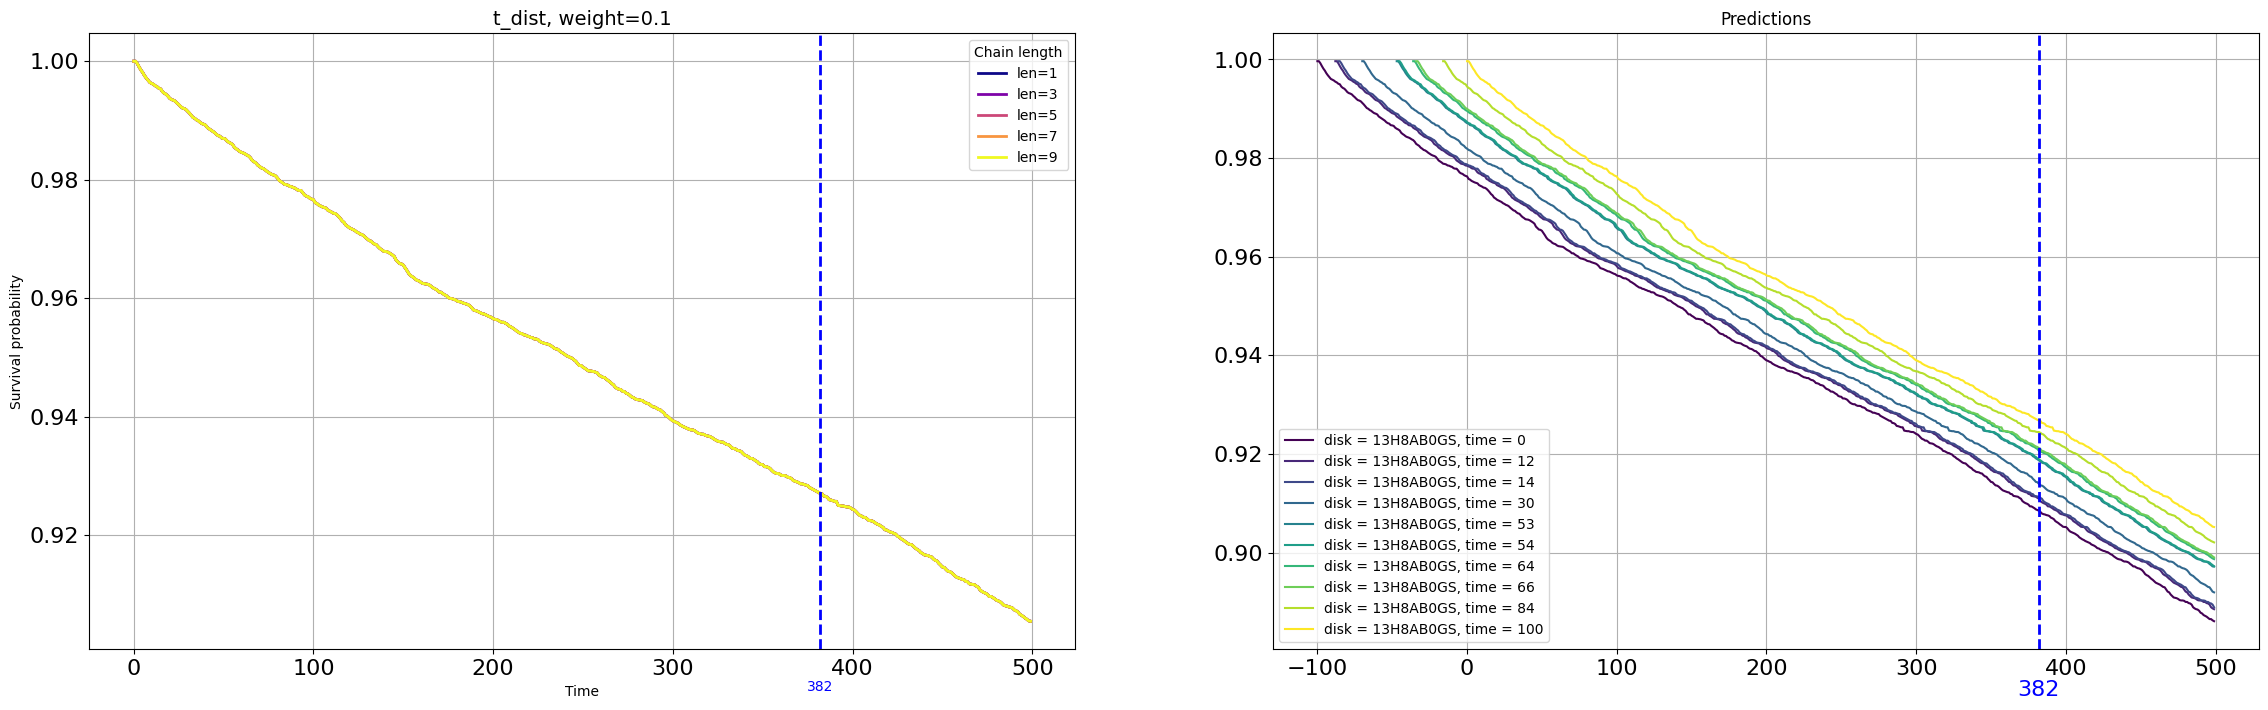

In [38]:
TICK_SIZE = 16
fig, axes = plt.subplots(1, 2, figsize=(28, 8))
axes[0].tick_params(labelsize=TICK_SIZE)
axes[1].tick_params(labelsize=TICK_SIZE)

LAST_OBSERV_N = 10
# SERIAL_NUMBER = 'W3006CRJ'
SERIAL_NUMBER = '13H8AB0GS'


plot_disk_predictions(X_pred, SERIAL_NUMBER, LAST_OBSERV_N, 10,  TIMES, ax= axes[1], shift_pred=True, X_gt=X_gt, max_times = 500)
df, event, duration = get_chain_survival_predictions_for_disk(
    X_pred, SERIAL_NUMBER, TIMES, sample_grid=range(1, 10, 2), 
    pred_agg=pred_agg, agg_method=AGG_MODE, agg_weight=AGG_WEIGHT, X_gt = X_gt, last_observ_n=LAST_OBSERV_N
)
plot_survival_chains(df, TIMES, ax= axes[0], plot_event = True, duration = duration, event = event, max_times = 500)
plt.legend()

<Axes: title={'center': 't_dist, weight=0.1'}, xlabel='Time', ylabel='Survival probability'>

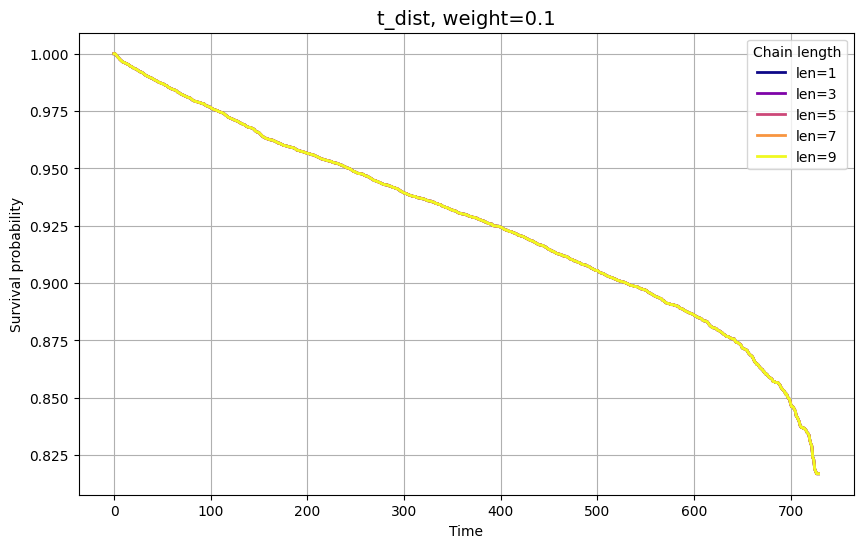

In [36]:

plot_survival_chains(df, TIMES)

# Сравнение бейзланов CoxPH и CoxTV

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from disk_analyzer.models.Cox import CoxTimeVaryingFitter, CoxTimeInvariantSNFitter, CoxTimeInvariantLNFitter 
from disk_analyzer.models.SurvPredictor import SurvPredictor
def load_model(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model

In [2]:
coxtv: CoxTimeVaryingFitter = load_model('Artifacts/Exp_76/models/1_CoxTV_model.pkl')
coxphsn: CoxTimeInvariantSNFitter = load_model('Artifacts/Exp_77/models/1_CoxTISN_model.pkl')
coxphln: CoxTimeInvariantLNFitter = load_model('Artifacts/Exp_74/models/7_CoxTILN_model.pkl')
surv_predictor = load_model('Artifacts/Exp_70/models/6_SP_model.pkl')

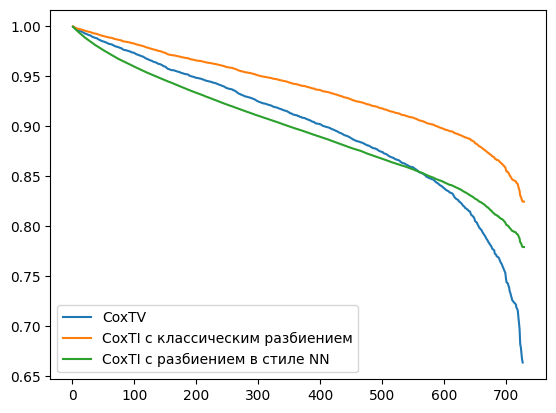

In [3]:
plt.plot(coxtv.baseline_survival_, label='CoxTV')
plt.plot(coxphsn.baseline_survival_, label='CoxTI с классическим разбиением')
plt.plot(coxphln.baseline_survival_, label = 'CoxTI с разбиением в стиле NN')
plt.legend()


In [4]:
from torch.utils.data import DataLoader
from Agg import sample_first_observations, TRAIN_BATCHSIZE
from disk_analyzer.stages.model_scoring import ModelScorer
from disk_analyzer.utils.constants import TIMES
from disk_analyzer.models.Dataset import DiskDataset
from disk_analyzer.research.aggregation.predictions_aggregator import PredictionsAggregator
# import sns as seaborn
SAMPLE_GRID = [1, 2, 5, 10]
TEST_PATH = 'Preprocessed_new/30_25_test_preprocessed.csv'
dl_test = DataLoader(
            dataset=DiskDataset(
                'score', [TEST_PATH]),
            batch_size=TRAIN_BATCHSIZE)
df_test = pd.read_csv(TEST_PATH).sort_values(by=['serial_number', 'time'])
df_test = df_test[df_test['time'] != df_test['max_lifetime']]
pred_agg = PredictionsAggregator('n_dist')
times_extended = pred_agg.get_extended_times(df_test, times=TIMES)

df_tv_pred, df_tv_gt = coxtv.predict(dl_test, times_extended)
df_tisn_pred, df_tisn_gt = coxphsn.predict(dl_test, times_extended)
df_tiln_pred, df_tiln_gt = coxphln.predict(dl_test, times_extended)
df_sp_pred, df_sp_gt = surv_predictor.predict(dl_test, times_extended)

df_tv_pred.sort_values(by=['serial_number', 'time'], inplace= True), df_tv_gt.sort_values(by=['serial_number', 'time'], inplace= True)
df_tisn_pred.sort_values(by=['serial_number', 'time'], inplace= True), df_tisn_gt.sort_values(by=['serial_number', 'time'], inplace= True)
df_tiln_pred.sort_values(by=['serial_number', 'time'], inplace= True), df_tiln_gt.sort_values(by=['serial_number', 'time'], inplace= True)
df_sp_pred.sort_values(by=['serial_number', 'time'], inplace= True), df_sp_gt.sort_values(by=['serial_number', 'time'], inplace= True)


100%|██████████| 209/209 [02:27<00:00,  1.41it/s]


(None, None)

In [5]:
df_tv_sampled = sample_first_observations(df_tv_pred, SAMPLE_GRID)
df_tisn_sampled = sample_first_observations(df_tisn_pred, SAMPLE_GRID)
df_tiln_sampled = sample_first_observations(df_tiln_pred, SAMPLE_GRID)
df_sp_sampled = sample_first_observations(df_sp_pred, SAMPLE_GRID)


In [6]:
def get_agg_predictions(model, df_pred, df_gt):
    cur_timeshift = df_pred.groupby('serial_number')['time'].transform('max') - df_pred['time']
    df_agg = model.predict(df_pred, times = TIMES, timeshift=cur_timeshift)
    df_new_gt = df_gt.loc[df_pred[df_pred['time'] == df_pred.groupby('serial_number')['time'].transform('max')].index, :]
    return df_agg, df_new_gt
    

In [7]:
coxtv.summary()
# coxphsn: CoxTimeInvariantSNFitter = load_model('Artifacts/Exp_77/models/1_CoxTISN_model.pkl')
# coxphln: CoxTimeInvariantLNFitter = load_model('Artifacts/Exp_74/models/7_CoxTILN_model.pkl')
# surv_predictor = load_model('Artifacts/Exp_70/models/6_SP_model.pkl')

TypeError: 'DataFrame' object is not callable

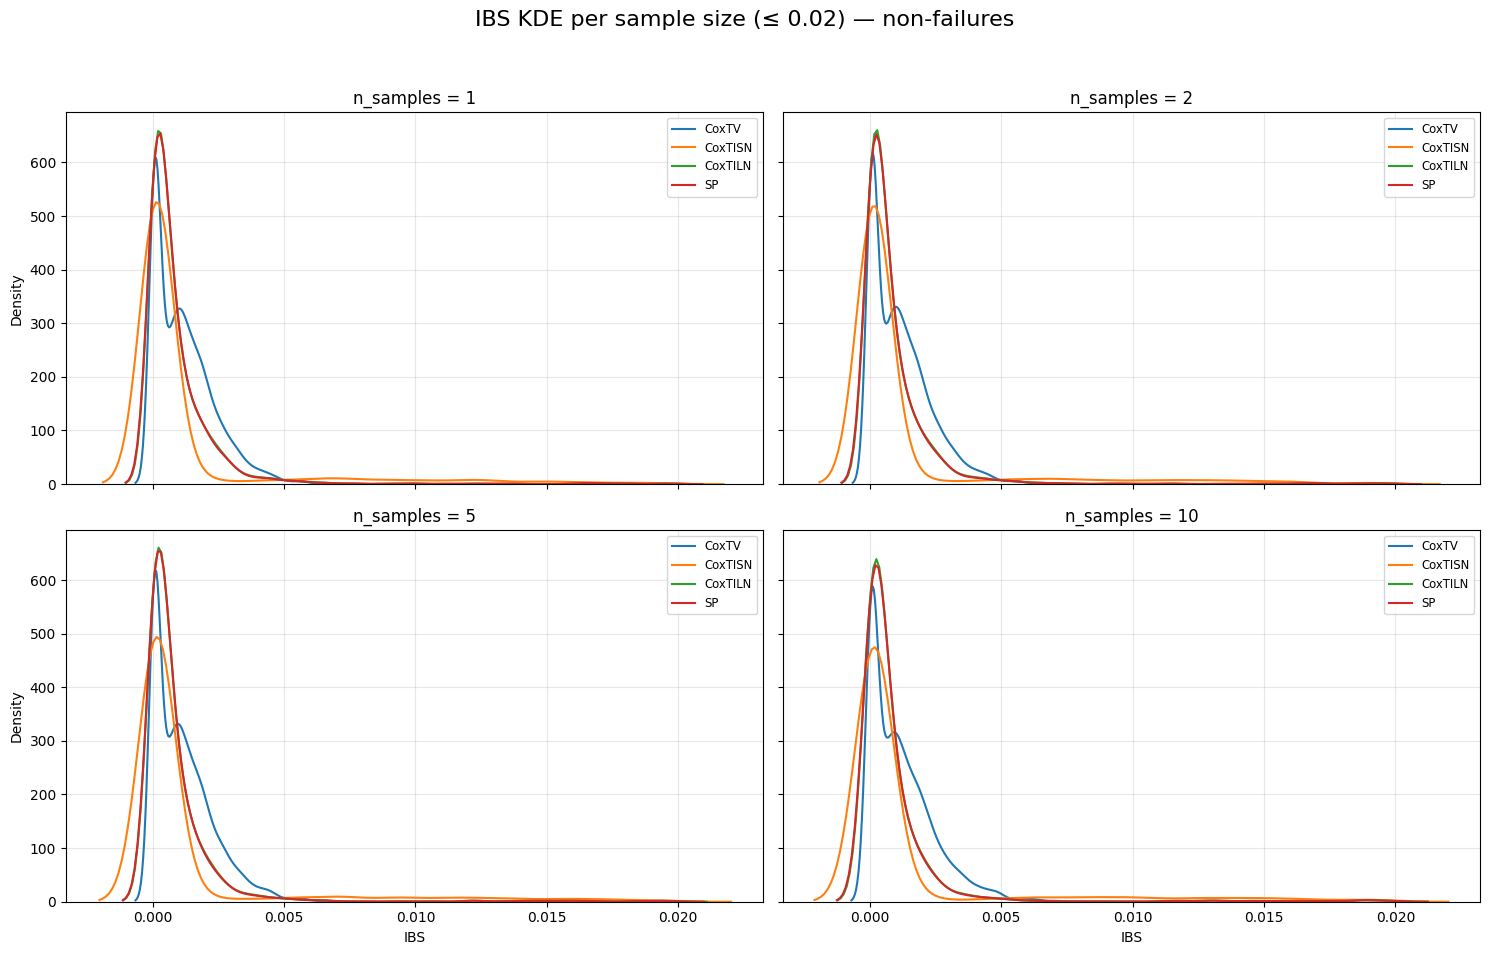

In [9]:
import math
import numpy as np
scorer = ModelScorer()
AGG_MODE = 'n_dist'
AGG_WEIGHT = 0.9
model = PredictionsAggregator('n_dist', 0.9)

ibs_thresh = 0.02        # или None для отключения порога
failure_filter = False   # None / True / False

n_plots = len(SAMPLE_GRID)
ncols = min(4, int(math.ceil(math.sqrt(n_plots))))
nrows = int(math.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(15, 10),
                         sharex=True, sharey=True)

if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

for i, n_samples in enumerate(SAMPLE_GRID):
    ax = axes[i]

    # Агрегируем предсказания для каждой из трёх конфигураций
    df_tv_agg, df_tv_new_gt = get_agg_predictions(model, df_tv_sampled[n_samples], df_tv_gt)
    df_tisn_agg, df_tisn_new_gt = get_agg_predictions(model, df_tisn_sampled[n_samples], df_tisn_gt)
    df_tiln_agg, df_tiln_new_gt = get_agg_predictions(model, df_tiln_sampled[n_samples], df_tiln_gt)
    df_sp_agg, df_sp_new_gt = get_agg_predictions(model, df_sp_sampled[n_samples], df_tiln_gt)


    # Получаем метрики IBS для каждой модели
    metrics_tv = scorer.get_metrics(model, df_tv_agg, df_tv_new_gt, TIMES, metrics=['ibs'], axis=0)['ibs']
    metrics_tisn = scorer.get_metrics(model, df_tisn_agg, df_tisn_new_gt, TIMES, metrics=['ibs'], axis=0)['ibs']
    metrics_tiln = scorer.get_metrics(model, df_tiln_agg, df_tiln_new_gt, TIMES, metrics=['ibs'], axis=0)['ibs']
    metrics_sp = scorer.get_metrics(model, df_sp_agg, df_sp_new_gt, TIMES, metrics=['ibs'], axis=0)['ibs']

    # Собираем все в один DataFrame для удобной фильтрации
    df_tv = pd.DataFrame({
        'ibs': pd.to_numeric(np.asarray(metrics_tv), errors='coerce'),
        'failure': np.asarray(df_tv_new_gt['failure']),
        'model': 'CoxTV',
        'serial_number': df_tv_new_gt['serial_number'],
        'time': df_tv_new_gt['time']
    })

    df_tisn = pd.DataFrame({
        'ibs': pd.to_numeric(np.asarray(metrics_tisn), errors='coerce'),
        'failure': np.asarray(df_tisn_new_gt['failure']),
        'model': 'CoxTISN',
        'serial_number': df_tisn_new_gt['serial_number'],
        'time': df_tisn_new_gt['time']
    })

    df_tiln = pd.DataFrame({
        'ibs': pd.to_numeric(np.asarray(metrics_tiln), errors='coerce'),
        'failure': np.asarray(df_tiln_new_gt['failure']),
        'model': 'CoxTILN',
        'serial_number': df_tiln_new_gt['serial_number'],
        'time': df_tiln_new_gt['time']
    })

    df_sp = pd.DataFrame({
        'ibs': pd.to_numeric(np.asarray(metrics_tiln), errors='coerce'),
        'failure': np.asarray(df_sp_new_gt['failure']),
        'model': 'SP',
        'serial_number': df_sp_new_gt['serial_number'],
        'time': df_sp_new_gt['time']
    })

    df_all = pd.concat([df_tv, df_tisn, df_tiln, df_sp], ignore_index=True)
    
    df_all['n_samples'] = n_samples
    df_all['agg_mode'] = AGG_MODE
    df_all['agg_weight'] = AGG_WEIGHT
    df_all.to_csv(f'{n_samples}.csv')

    # Применяем фильтр failure, если задан
    if failure_filter is True:
        df_all = df_all[df_all['failure'] == True]
    elif failure_filter is False:
        df_all = df_all[df_all['failure'] == False]
    # если failure_filter is None, не фильтруем по failure

    # Применяем порог ibs_thresh, если задан
    if ibs_thresh is not None:
        try:
            thr = float(ibs_thresh)
            df_all = df_all[df_all['ibs'] <= thr]
        except Exception:
            thr = None

    # Рисуем KDE для каждой модели отдельно (если есть данные)
    for model_name in ['CoxTV', 'CoxTISN', 'CoxTILN', 'SP']:
        subset = df_all[df_all['model'] == model_name]['ibs']
        sns.kdeplot(subset, ax=ax, label=model_name)


    ax.set_title(f'n_samples = {n_samples}')
    ax.set_xlabel('IBS')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.3)
    ax.legend(fontsize='small')

# Скрыть пустые оси, если есть
for j in range(len(SAMPLE_GRID), len(axes)):
    axes[j].set_visible(False)

suptitle = 'IBS KDE per sample size'
if ibs_thresh is not None and 'thr' in locals() and thr is not None:
    suptitle += f' (≤ {thr})'
if failure_filter is True:
    suptitle += ' — failures'
elif failure_filter is False:
    suptitle += ' — non-failures'

fig.suptitle(suptitle, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_kde_stratified(
    df_pred_samples,
    df_gt,
    model,
    sample_grid,
    times,
    metric='ibs',
    scorer=None,
    failure_col='failure',
    ncols=None,
    figsize=None,
    bw_adjust=1,
    fill=False,
    sharex=True,
    sharey=True,
    title_prefix=None,
    palette=None,
    ibs_thresh = 1,
):

    n_plots = len(sample_grid)
    if ncols is None:
        ncols = min(4, int(math.ceil(math.sqrt(n_plots))))
    nrows = int(math.ceil(n_plots / ncols))
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=sharex, sharey=sharey)
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, n_samples in enumerate(sample_grid):
        ax = axes[i]

        df_pred = df_pred_samples[n_samples]

        df_pred_agg, df_gt_new = get_agg_predictions(model, df_pred, df_gt)
        

        metrics = scorer.get_metrics(model, df_pred_agg, df_gt_new, times, metrics=[metric], axis=0)

        values = np.asarray(metrics[metric])
        failure = np.asarray(df_gt_new[failure_col])

        df_plot = pd.DataFrame({metric: values, failure_col: failure})
        df_plot[failure_col] = df_plot[failure_col].astype('category')
        df_plot = df_plot.dropna(subset=[metric, failure_col])

        thr = ibs_thresh

        if thr is not None:
            # приводим к числовому типу и отфильтровываем
            df_plot[metric] = pd.to_numeric(df_plot[metric], errors='coerce')
            df_plot = df_plot.dropna(subset=[metric])
            df_plot_filtered = df_plot[df_plot[metric] <= thr]
        else:
            df_plot_filtered = df_plot

        # Рисуем KDE только для отфильтрованных значений
        sns.kdeplot(data=df_plot_filtered, x=metric, hue=failure_col, ax=ax,
                        bw_adjust=bw_adjust, fill=fill, palette=palette)

        # Оформление
        title = f'n_samples = {n_samples}'
        ax.set_title(title)
        ax.set_xlabel(metric.upper())
        ax.set_ylabel('Density')
        ax.grid(alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(handles, labels, fontsize='small')

    # скрыть пустые оси, если есть
    for j in range(len(sample_grid), len(axes)):
        axes[j].set_visible(False)

    suptitle = f'{metric.upper()} KDE stratified by {failure_col}'
    if title_prefix:
        suptitle = f"{title_prefix}, " + suptitle

    fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig, axes

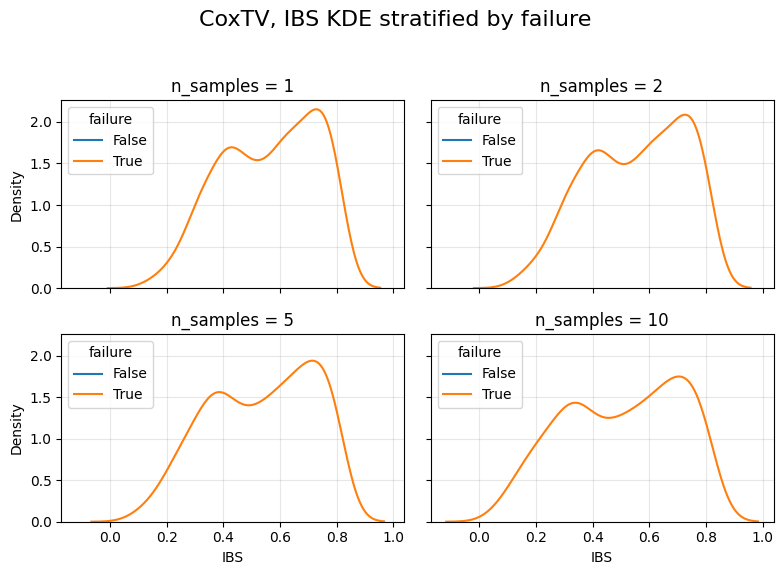

(<Figure size 800x600 with 4 Axes>,
 array([<Axes: title={'center': 'n_samples = 1'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 2'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 5'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 10'}, xlabel='IBS', ylabel='Density'>],
       dtype=object))

In [ ]:
plot_kde_stratified(df_pred_samples=df_tv_sampled, df_gt=df_tv_gt, model = model, sample_grid=SAMPLE_GRID, times=TIMES,scorer= scorer, title_prefix='CoxTV')

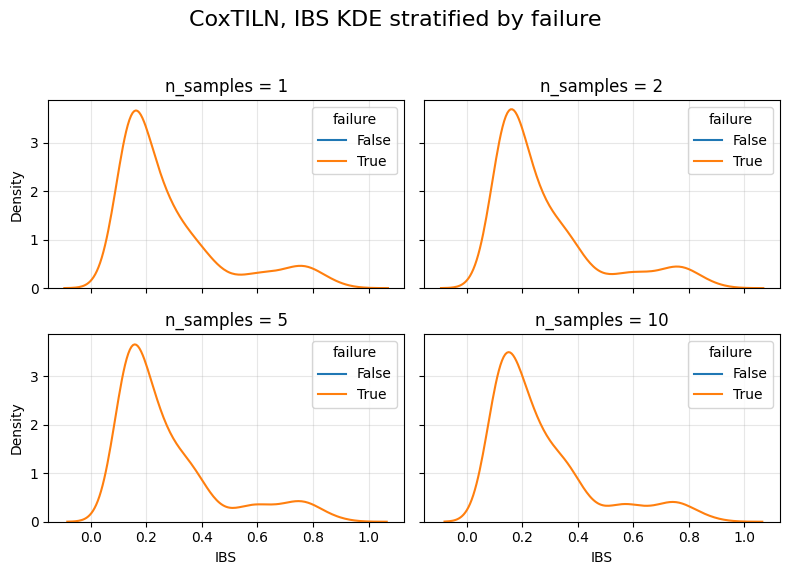

(<Figure size 800x600 with 4 Axes>,
 array([<Axes: title={'center': 'n_samples = 1'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 2'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 5'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 10'}, xlabel='IBS', ylabel='Density'>],
       dtype=object))

In [ ]:
plot_kde_stratified(df_pred_samples=df_tiln_sampled, df_gt=df_tiln_gt, model = model, sample_grid=SAMPLE_GRID, times=TIMES,scorer= scorer, title_prefix='CoxTILN')


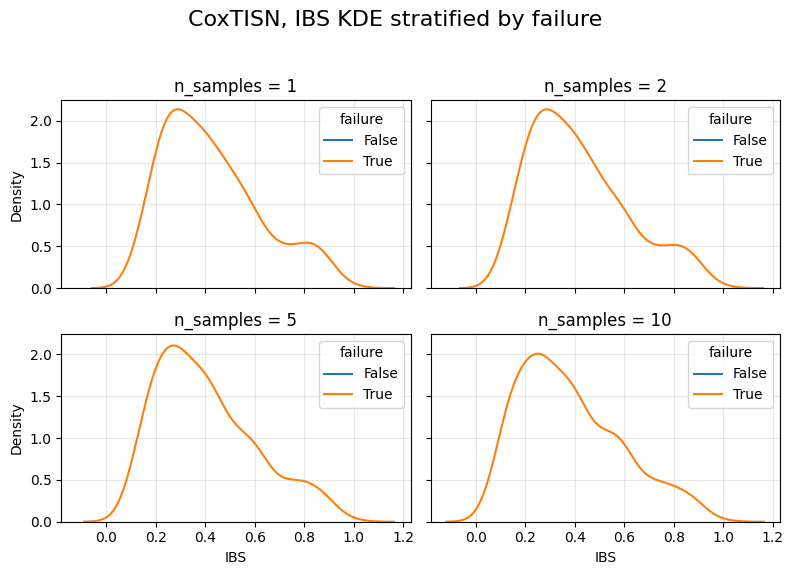

(<Figure size 800x600 with 4 Axes>,
 array([<Axes: title={'center': 'n_samples = 1'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 2'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 5'}, xlabel='IBS', ylabel='Density'>,
        <Axes: title={'center': 'n_samples = 10'}, xlabel='IBS', ylabel='Density'>],
       dtype=object))

In [ ]:
plot_kde_stratified(df_pred_samples=df_tisn_sampled, df_gt=df_tisn_gt, model = model, sample_grid=SAMPLE_GRID, times=TIMES,scorer= scorer, title_prefix='CoxTISN')
